# Image Steganography

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Encoding

Converting the Hidden Message to Binary Form  

In [ ]:
def hidden_message_to_binary(hidden_message, end_character="!"):
    """
    Converts the hidden message to binary format
    hidden_message (string): the message to be encoded
    end character (character): the character which describes the end of sentence (Default is "!")
    """
    # end the end character
    hidden_message = hidden_message + end_character

    # convert the characters to their ascii values
    ascii_values = list(hidden_message.encode("ascii"))

    # convert the ascii values to binary representation
    hidden_message_binary = [np.binary_repr(ascii_code, width=8) for ascii_code in ascii_values]

    # join the elements in the list to form a string
    hidden_message_binary = "".join([np.binary_repr(ascii_code, width=8) for ascii_code in ascii_values])

    # convert it to a numpy array of dtype "int64"
    hidden_message_binary= np.array(list(hidden_message_binary), dtype="int64")

    return hidden_message_binary

Performing Bit-Plane-Slicing

In [ ]:
def bitPlaneSlicing(img, bit_plane):
    """
    img: gray scale image
    bit_plane: sliced place given as output
          1 -> least significant bit plane
          8 -> most significant bit plane
    """
    dec = np.binary_repr(img, width = 8)
    return int(dec[8-bit_plane])

bitPlaneSlicingVec = np.vectorize(bitPlaneSlicing)

Encoding the Mesaage into Image

In [ ]:
def add_code_to_bit_plane(bit_plane, binary_message):
    """
    Takes input as the bit plane and binary message
    and encodes the message to the bit plane.

    Arguments:
        bit_plane (np.ndarray): the bit plane which is returned by the func bitPlaneSlicing
        binary message (np.ndarray): the binary form of hidden message as returned by
        hidden_message_to_binary
    """
    bit_plane_flattened = bit_plane.flatten()
    len_binary_coded = len(binary_message)
    bit_plane_flattened[:len_binary_coded] = binary_message
    bit_plane_coded = bit_plane_flattened.reshape(bit_plane.shape)
    return bit_plane_coded

In [ ]:
def add_bit_plane_back_to_image(img, bit_plane):
    #Iterate over each pixel and change pixel value to binary using np.binary_repr() and store it in a list.
    lst = []
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
             lst.append(np.binary_repr(img[i][j] ,width=8)) # width = no. of bits

    # We have a list of strings where each string represents binary pixel value. To extract bit planes we need to iterate over the strings and store the characters corresponding to bit planes into lists.
    # Multiply with 2^(n-1) and reshape to reconstruct the bit image.
    eight_bit_img = (np.array([int(i[0]) for i in lst],dtype = np.uint8) * 128).reshape(img.shape[0],img.shape[1])
    seven_bit_img = (np.array([int(i[1]) for i in lst],dtype = np.uint8) * 64).reshape(img.shape[0],img.shape[1])
    six_bit_img = (np.array([int(i[2]) for i in lst],dtype = np.uint8) * 32).reshape(img.shape[0],img.shape[1])
    five_bit_img = (np.array([int(i[3]) for i in lst],dtype = np.uint8) * 16).reshape(img.shape[0],img.shape[1])
    four_bit_img = (np.array([int(i[4]) for i in lst],dtype = np.uint8) * 8).reshape(img.shape[0],img.shape[1])
    three_bit_img = (np.array([int(i[5]) for i in lst],dtype = np.uint8) * 4).reshape(img.shape[0],img.shape[1])
    two_bit_img = (np.array([int(i[6]) for i in lst],dtype = np.uint8) * 2).reshape(img.shape[0],img.shape[1])

    final_image = eight_bit_img + seven_bit_img + six_bit_img + five_bit_img + four_bit_img + three_bit_img + two_bit_img + bit_plane.astype("uint8")
    return final_image

Creating the Encoder

In [ ]:
def encoder(image, text):
  binary_text = hidden_message_to_binary(text)
  #image = cv2.imread(img)
  # we will be using any one channel (in this case, only blue channel)
  b1,g1,r1 = cv2.split(image)
  p = bitPlaneSlicingVec(b1, 1)
  p_coded = add_code_to_bit_plane(p, binary_text)
  final_img_b = add_bit_plane_back_to_image(b1, p_coded)
  final_img = cv2.merge((final_img_b, g1, r1))
  #creates Image(coded_image.png) which is the image containg the message
  cv2.imwrite("coded_image.png", final_img)
  plt.imshow(cv2.imread("/content/coded_image.png"))

# Decoding

Converting to Character from Binary

In [ ]:
def binary_repr_to_ch(binary_array):
    binary_value = "".join(binary_array.astype('str'))
    ascii_code = int(binary_value, 2)
    character = chr(ascii_code)
    return character

Extracting the Hidden Message

In [ ]:
def get_message_from_plane(plane, end_character = "!"):
    plane_flatten = plane.flatten()
    plane_flatten = plane_flatten[:len(plane_flatten) - len(plane_flatten)%8]
    plane_reshaped = plane_flatten.reshape(-1, 8)

    sentence = []
    for binary_repr in plane_reshaped:
        character = binary_repr_to_ch(binary_repr)
        if character == end_character:
            break
        sentence.append(character)

    return "".join(sentence)

Creating the Image Decoder

In [ ]:
def decoder(image, end_character="!"):
    """
    image: single channel image, where message is being hidden in the
            lowest bit plane
    end character: the character denoting the end of hidden message
    """
    image = cv2.imread(image)
    r, _, _ = cv2.split(image)
    lowest_bit_plane = bitPlaneSlicingVec(r, 1)

    message = get_message_from_plane(lowest_bit_plane)

    return message


# Testing

Example 1

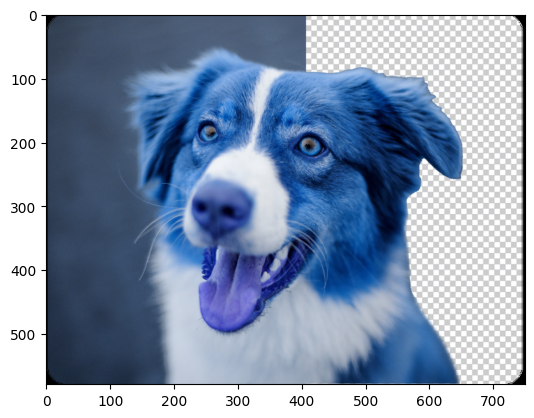

In [ ]:
encoder(cv2.imread('/content/s.png'), "tomorrow is a holiday")

In [ ]:
decoder('/content/coded_image.png')

'tomorrow is a holiday'

Example 2

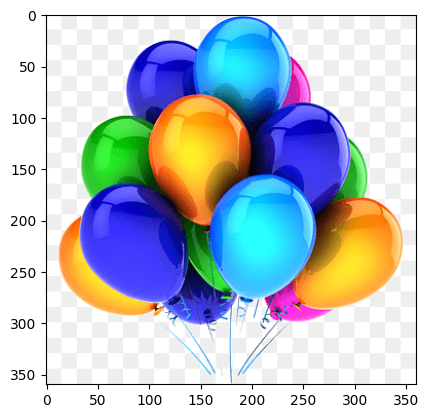

In [ ]:
encoder(cv2.imread('/content/spg.png'), "the game is on...")

In [ ]:
decoder('/content/coded_image.png')

'the game is on...'